In [1]:
import os 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import cv2 
import sys 


In [2]:
from scipy.ndimage import uniform_filter
from scipy import linalg
minmax_normalise = lambda x: (x - x.min()) / (x.max() - x.min())

def detect_edge_from_kymograph(kymograph):
    """
    Detect the edges of the kymograph based on a Canny edge detection algorithm.
    """
    import cv2
    from scipy.ndimage import uniform_filter

    # Convert kymograph to grayscale if it is not already
    if len(kymograph.shape) == 3:
        kymograph_gray = cv2.cvtColor(kymograph, cv2.COLOR_BGR2GRAY)
    else:
        kymograph_gray = kymograph
    
    kymograph_filtered = uniform_filter(kymograph_gray, size=(6, 6), mode='nearest')
    kymograph_normalised = (kymograph_filtered - kymograph_filtered.min()) / (kymograph_filtered.max() - kymograph_filtered.min())
    kymograph_binarised = (kymograph_normalised < 0.5).astype(np.uint8)  # Binarise the kymograph
    # Apply Canny edge detection

    edges = cv2.Canny(kymograph_binarised, 0.2, 0.8)
    # return normalised values for edges 
    edges_normalised = edges / edges.max()
    edges_binarised = (edges_normalised > 0.5).astype(int)  # Binarise the edges
    return edges_binarised

def isolate_mask(frame):
    from scipy.ndimage import label
    from scipy.ndimage import gaussian_filter

    # normalise the frame
    frame_normalised = minmax_normalise(frame)
    # create a mask
    mask = np.zeros_like(frame)
    # threshold the frame to create a mask
    percentile_threshold = 30
    threshold_value = np.percentile(frame_normalised, percentile_threshold)
    mask[frame_normalised > threshold_value] = 1
    # inverse the mask
    mask = 1 - mask
    # use scipy label to find connected components
    labeled_mask, num_features = label(mask)
    
    horizontal_center = mask.shape[0] // 2
    for i in range(num_features):
        y, x = np.where(labeled_mask == i + 1)
        center_y = mask.shape[0] // 2
        center_x = mask.shape[1] // 2
        center_of_mass_is_near_horizontal_center = np.abs(np.mean(y) - center_y) < 10
        feature_size = np.sum(labeled_mask == i + 1)
        feature_size_is_big_enough = feature_size > 500
        if center_of_mass_is_near_horizontal_center and feature_size_is_big_enough:
            continue
        else:
            labeled_mask[labeled_mask == i + 1] = 0
    
    # smoothen the edges of the mask
    labeled_mask = gaussian_filter(labeled_mask.astype(float), sigma=5)
    labeled_mask = minmax_normalise(labeled_mask)
    labeled_mask = (labeled_mask > 0.5).astype(int)
    return labeled_mask

def subtract_linear_plane(img):
    ny, nx = img.shape
    Y, X = np.mgrid[:ny, :nx]
    # flatten into vectors
    x = X.ravel()
    y = Y.ravel()
    z = img.ravel()
    # design matrix [x y 1]
    A = np.vstack([x, y, np.ones_like(x)]).T
    # solve for plane coefficients a, b, c minimizing |Ax - z|
    a, b, c = linalg.lstsq(A, z)[0]
    # rebuild the fitted plane
    plane = (a*X + b*Y + c)
    return img - plane

def preprocess_frame(frame, filter_size=6, sideview=False):
    if sideview:
        isolation_mask = isolate_mask(frame)
        return isolation_mask
    else:
        linear_plane_subtracted = subtract_linear_plane(frame)
        line_intensities_filtered = uniform_filter(linear_plane_subtracted, size=(filter_size, filter_size), mode='nearest')
        return line_intensities_filtered

In [3]:
front_kymograph_file = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/kymographs/kymograph_depth_3.0mm_0703_to_0766_autogrid_front_vid_2025-07-21_19-28-45.mp4.npy"
side_kymograph_file = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/kymographs/kymograph_depth_3.0mm_0684_to_0747_autogrid_side_vid_2025-07-21_19-25-39.mp4.npy"

apix = 21.2e-6 
frame_rate = 5406 
sampling_time = 1 / frame_rate

front_kymograph = np.load(front_kymograph_file)
side_kymograph = np.load(side_kymograph_file)

front_edges = detect_edge_from_kymograph(front_kymograph)
side_edges = detect_edge_from_kymograph(side_kymograph)

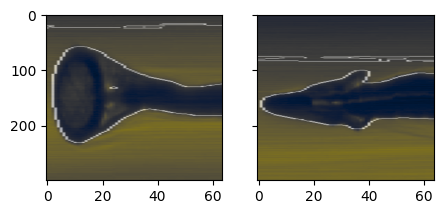

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(5, 3), sharey=True, sharex=True)
ax[0].imshow(front_kymograph, cmap='cividis', aspect=0.2)
ax[0].imshow(front_edges, cmap='gray', alpha=0.5, aspect=0.2)
ax[1].imshow(side_kymograph, cmap='cividis', aspect=0.2)
ax[1].imshow(side_edges, cmap='gray', alpha=0.5, aspect=0.2)

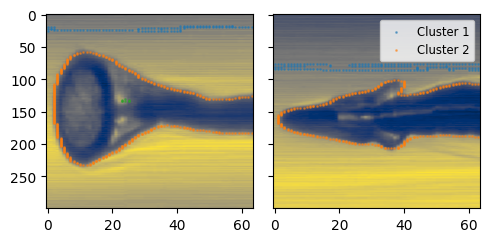

In [5]:
def detect_peaks_and_cluster(edges, eps=5, min_samples=10):
    from sklearn.cluster import DBSCAN
    # Find coordinates of edge pixels
    # normalize the edges to range [0, 1] for better clustering
    edges = edges / np.max(edges)
    y_indices, x_indices = np.where(edges > 0.5)
    points = np.column_stack((x_indices, y_indices))
    
    # Perform DBSCAN clustering
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(points)
    
    # Filter out noise points (label -1)
    clusters = [points[labels == label] for label in set(labels) if label != -1]
    
    return clusters


front_clusters = detect_peaks_and_cluster(front_edges, eps=4, min_samples=3)
side_clusters = detect_peaks_and_cluster(side_edges, eps=4, min_samples=3)
fig, ax = plt.subplots(1, 2, figsize=(5, 3), sharey=True, sharex=True)
ax[0].imshow(front_kymograph, cmap='cividis', aspect=0.2)
for i, cluster in enumerate(front_clusters):
    ax[0].scatter(cluster[:, 0], cluster[:, 1], s=1, alpha=0.5, label=f'Cluster {i+1}')
#ax[0].legend(loc='upper right', fontsize='small')
ax[1].imshow(side_kymograph, cmap='cividis', aspect=0.2)
for i, cluster in enumerate(side_clusters):
    ax[1].scatter(cluster[:, 0], cluster[:, 1], s=1, alpha=0.5, label=f'Cluster {i+1}')
ax[1].legend(loc='upper right', fontsize='small')
plt.tight_layout()


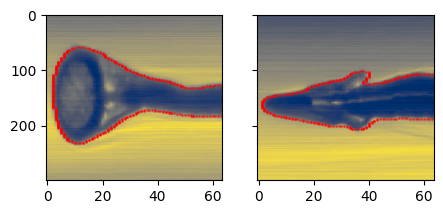

In [6]:
# find out which cluster dominate the center of the frame 
def centroid_to_center(clusters, frame_shape, threshold=0.1):
    center_x = frame_shape[1] // 2
    center_y = frame_shape[0] // 2
    
    distance_to_frame_center = {}
    for i, cluster in enumerate(clusters):
        centroid = np.mean(cluster, axis=0)
        #distance = np.linalg.norm(centroid - np.array([center_x, center_y]))
        # measure distance to the horizontal center line of the frame
        distance = abs(centroid[1] - center_y)
        size_of_cluster = len(cluster)
        distance_to_frame_center[i] = [distance, size_of_cluster]
    
    cluster_with_min_distance = min(distance_to_frame_center, key=lambda k: distance_to_frame_center[k][0])
    #print(f"Cluster {cluster_with_min_distance} is closest to the center with distance {distance_to_frame_center[cluster_with_min_distance][0]} and size {distance_to_frame_center[cluster_with_min_distance][1]}")
    
    #for i, (distance, size) in distance_to_frame_center.items():
        #print(f"Cluster {i}: distance = {distance}, size = {size}")
    
    return distance_to_frame_center

# filter only the cluster wiht the lowest distance 
def get_closest_cluster_to_center(all_distances):
    closest_clusters = []
    for i, distances in enumerate(all_distances):
        # sort distances by the distance to the center
        sorted_distances = sorted(distances.items(), key=lambda item: item[1][0])
        # get the cluster with the minimum distance and size greater than 50
        cluster_size_threshold = 125
        cluster_with_min_distance = next((k for k, v in sorted_distances if v[1] > cluster_size_threshold), None)
        if cluster_with_min_distance is None:
            print("No cluster found with size greater than threshold frame: {}".format(i))

        closest_clusters.append(cluster_with_min_distance)
    return closest_clusters


front_distance_to_center = centroid_to_center(front_clusters, front_kymograph.shape)
side_distance_to_center = centroid_to_center(side_clusters, side_kymograph.shape)

front_closest_clusters = get_closest_cluster_to_center([front_distance_to_center])
side_closest_clusters = get_closest_cluster_to_center([side_distance_to_center])

x_points_front_closest = front_clusters[front_closest_clusters[0]][:, 0]
y_points_front_closest = front_clusters[front_closest_clusters[0]][:, 1]

x_points_side_closest = side_clusters[side_closest_clusters[0]][:, 0]
y_points_side_closest = side_clusters[side_closest_clusters[0]][:, 1]

fig, ax = plt.subplots(1, 2, figsize=(5, 3), sharey=True, sharex=True)
ax[0].imshow(front_kymograph, cmap='cividis', aspect=0.2)
ax[0].scatter(x_points_front_closest, y_points_front_closest, s=1, alpha=0.5, color='red')
ax[1].imshow(side_kymograph, cmap='cividis', aspect=0.2)
ax[1].scatter(x_points_side_closest, y_points_side_closest, s=1, alpha=0.5, color='red')


In [7]:
def get_yrange_at_each_x(edges_x, edges_y):
    edges_x_unique = np.unique(edges_x)
    thickness_at_ex = {}
    for ex in edges_x_unique:
        indices = np.where(edges_x == ex)[0]
        y_values_at_ex = edges_y[indices]
        max_y_at_ex = np.max(y_values_at_ex)
        min_y_at_ex = np.min(y_values_at_ex)
        thickness_at_ex[ex] = {
            "max_y": max_y_at_ex,
            "min_y": min_y_at_ex,
            "delta": (max_y_at_ex - min_y_at_ex) 
        }
    return thickness_at_ex

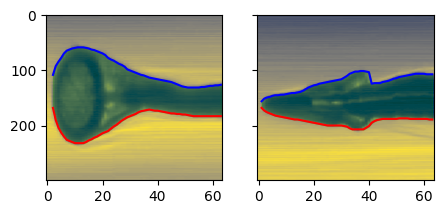

In [8]:
front_thickness_at_ex = get_yrange_at_each_x(x_points_front_closest, y_points_front_closest)
side_thickness_at_ex = get_yrange_at_each_x(x_points_side_closest, y_points_side_closest)

x_unique_front = np.array(list(front_thickness_at_ex.keys()))
x_unique_side = np.array(list(side_thickness_at_ex.keys()))
y_max_front = np.array([front_thickness_at_ex[x]['max_y'] for x in x_unique_front])
y_min_front = np.array([front_thickness_at_ex[x]['min_y'] for x in x_unique_front])
y_max_side = np.array([side_thickness_at_ex[x]['max_y'] for x in x_unique_side])
y_min_side = np.array([side_thickness_at_ex[x]['min_y'] for x in x_unique_side])
fig, ax = plt.subplots(1, 2, figsize=(5, 3), sharey=True, sharex=True)
ax[0].imshow(front_kymograph, cmap='cividis', aspect=0.2)
ax[0].plot(x_unique_front, y_max_front, label='Max Y', color='red')
ax[0].plot(x_unique_front, y_min_front, label='Min Y', color='blue')
ax[0].fill_between(x_unique_front, y_max_front, y_min_front, color='green', alpha=0.3, label='Thickness')
ax[1].imshow(side_kymograph, cmap='cividis', aspect=0.2)
ax[1].plot(x_unique_side, y_max_side, label='Max Y', color='red')
ax[1].plot(x_unique_side, y_min_side, label='Min Y', color='blue')
ax[1].fill_between(x_unique_side, y_max_side, y_min_side, color='green', alpha=0.3, label='Thickness')


In [9]:
ellipse_parameters = []
for xx in x_unique_front:
    major_axis_length = front_thickness_at_ex[xx]['delta'] / 2
    minor_axis_length = side_thickness_at_ex[xx]['delta'] / 2
    ellipse_parameters.append([major_axis_length, minor_axis_length, xx])

ellipse_parameters_df = pd.DataFrame(ellipse_parameters, columns=['semi_major_axis', 'semi_minor_axis', 'time_axis_frame'])


In [10]:
theta = np.linspace(0, 2 * np.pi, 100)
all_times_df = {}
# initialize the dataframe with empty lists for each column
all_times_df["x_points_ellipse"] = []
all_times_df["y_points_ellipse"] = []
all_times_df["time_ms"] = []
for time_points_at_depth in x_unique_front:
    ellipse_at_time = ellipse_parameters_df[ellipse_parameters_df['time_axis_frame'] == time_points_at_depth]
    x_ellipse_points = ellipse_at_time["semi_major_axis"].values[0] * np.sin(theta) * apix * 1e3
    y_ellipse_points = ellipse_at_time["semi_minor_axis"].values[0] * np.cos(theta) * apix * 1e3
    time_points = time_points_at_depth * sampling_time 
    for x,y in zip(x_ellipse_points, y_ellipse_points):
        all_times_df["x_points_ellipse"].append(x)
        all_times_df["y_points_ellipse"].append(y)
        all_times_df["time_ms"].append(time_points * 1000)

all_times_df = pd.DataFrame(all_times_df)

Max Circularity: 0.9996105451372324 at time 5.549389567147614 ms


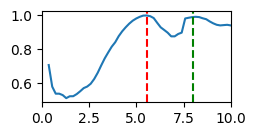

In [15]:
def measure_circularity(x_points, y_points):
    """Calculate the circularity of a set of points."""
    # Calculate the area using the shoelace formula
    area = 0.5 * np.abs(np.dot(x_points, np.roll(y_points, 1)) - np.dot(y_points, np.roll(x_points, 1)))
    
    # Calculate the perimeter using the distance between consecutive points
    perimeter = np.sum(np.sqrt(np.diff(x_points)**2 + np.diff(y_points)**2))
    
    # Calculate circularity
    circularity = (4 * np.pi * area) / (perimeter**2)
    
    return circularity

# Calculate circularity for each ellipse at each time point
circularity_values = []
times = []
for time in all_times_df['time_ms'].unique():
    if time > 10:  # Limit to 10 ms for better visualization
        continue    
    ellipse_points = all_times_df[all_times_df['time_ms'] == time]
    circularity = measure_circularity(ellipse_points['x_points_ellipse'], ellipse_points['y_points_ellipse'])
    circularity_values.append(circularity)
    times.append(time)
# Add circularity values to the DataFrame
figsize_mm = (62, 30)
fig, ax = plt.subplots(figsize=(figsize_mm[0] / 25.4, figsize_mm[1] / 25.4))
ax.plot(times, circularity_values)
argmax_circularity = np.argmax(circularity_values)
ax.axvline(all_times_df['time_ms'].unique()[argmax_circularity], color='r', linestyle='--', label='Max Circularity')
#ax.axvline(7, color='g', linestyle='--', label='7 ms')
ax.axvline(8, color='g', linestyle='--', label='8 ms')
ax.set_xticks([0, 2.5, 5, 7.5, 10])
ax.set_xlim(0, 10)
output_folder = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface/interface_phases/"
save_path = os.path.join(output_folder, "circularity_vs_time_10ms.pdf")
fig.savefig(save_path, bbox_inches='tight', dpi=600)
print(f"Max Circularity: {circularity_values[argmax_circularity]} at time {all_times_df['time_ms'].unique()[argmax_circularity]} ms")
# dump the circularity values to a csv file
circularity_df = pd.DataFrame({
    'time_ms': times,
    'circularity': circularity_values
})
circularity_csv_path = os.path.join(output_folder, "circularity_values.csv")
circularity_df.to_csv(circularity_csv_path, index=False)

/tmp/ipykernel_13242/1500253065.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels([0, 2.5, 5, 7.5, 10])


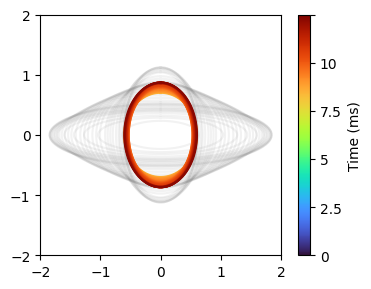

In [12]:
output_folder = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface/interface_phases/"
colors_time = sns.color_palette("turbo", len(all_times_df['time_ms'].unique()))

lower_bound = 8
upper_bound = 12
fig, ax = plt.subplots(figsize=(4, 3))
for i, time in enumerate(all_times_df['time_ms'].unique()):
    if time < lower_bound:
        alpha = 0.1
        color = "grey"
    elif lower_bound <= time <= upper_bound:
        alpha = 1
        color = colors_time[i]
    else:
        continue
    ellipse_points = all_times_df[all_times_df['time_ms'] == time]
    ax.plot(ellipse_points['x_points_ellipse'], ellipse_points['y_points_ellipse'], alpha=alpha, color=color)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_yticks([-2, -1, 0, 1, 2])
# set aspect ratio to be equal
ax.set_aspect('equal', adjustable='box')
output_file_path = os.path.join(output_folder, f"ellipses_from_kymographs_depth_3_time_range_{lower_bound}_{upper_bound}_with_cbar.pdf")
#plt.xlabel("X (mm)")
#plt.ylabel("Y (mm)")
# add colorbar
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap="turbo"), ax=ax)
cbar.set_label("Time (ms)")
#cbar.set_ticks(all_times_df['time_ms'].unique())
min_time = all_times_df['time_ms'].min()
max_time = all_times_df['time_ms'].max()
cbar.set_ticklabels([0, 2.5, 5, 7.5, 10])

fig.tight_layout()
#plt.savefig(output_file_path, bbox_inches='tight', dpi=600)


In [13]:
# save data to csv file
#output_csv_path = os.path.join(output_folder, "ellipse_parameters_depth_3_all_times.csv")
#ellipse_parameters_df.to_csv(output_csv_path, index=False)

In [14]:
def measure_laplace_pressure_from_point_cloud(x_data, y_data, surface_tension):
    # Measure the laplace pressure for an ellipse 
    major_axis_radius = (x_data.max() - x_data.min()) / 2 * 1e-3
    minor_axis_radius = (y_data.max() - y_data.min()) / 2 * 1e-3
    # Calculate maximum and minimum curvature
    k_max = major_axis_radius / (minor_axis_radius**2)
    k_min = minor_axis_radius / (major_axis_radius**2)
    # Calculate Laplace pressure
    laplace_pressure_max = surface_tension * k_max
    laplace_pressure_min = surface_tension * k_min
    #print(f"Max Laplace Pressure: {laplace_pressure_max} Pa")
    #print(f"Min Laplace Pressure: {laplace_pressure_min} Pa")
    return laplace_pressure_max, laplace_pressure_min




In [15]:
output_folder = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface/interface_phases/"
colors_time = sns.color_palette("turbo", len(all_times_df['time_ms'].unique()))
laplace_pressures_with_time = []
lower_bound = 0
upper_bound = 12
for i, time in enumerate(all_times_df['time_ms'].unique()):
    if time < lower_bound:
        alpha = 0.1
        color = "grey"
    elif lower_bound <= time <= upper_bound:
        alpha = 1
        color = colors_time[i]
    else:
        continue
    ellipse_points = all_times_df[all_times_df['time_ms'] == time]
    laplace_pressure_max, laplace_pressure_min = measure_laplace_pressure_from_point_cloud(ellipse_points['x_points_ellipse'], ellipse_points['y_points_ellipse'], surface_tension=0.025)
    laplace_pressures_with_time.append({
        "time_ms": time,
        "laplace_pressure_max": laplace_pressure_max,
        "laplace_pressure_min": laplace_pressure_min,
        "major_axis_radius": (ellipse_points['x_points_ellipse'].max() - ellipse_points['x_points_ellipse'].min()) / 2,
        "minor_axis_radius": (ellipse_points['y_points_ellipse'].max() - ellipse_points['y_points_ellipse'].min()) / 2
    })

Text(0, 0.5, 'Radius (mm)')

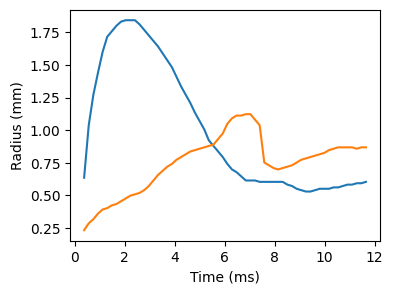

In [16]:
# Plot major and minor axis radii
laplace_pressures_df = pd.DataFrame(laplace_pressures_with_time)
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(laplace_pressures_df['time_ms'], laplace_pressures_df['major_axis_radius'], label='Major Axis Radius (mm)')
ax.plot(laplace_pressures_df['time_ms'], laplace_pressures_df['minor_axis_radius'], label='Minor Axis Radius (mm)')
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Radius (mm)")

Maximum Laplace Pressure: 317.1733564394717 Pa
Minimum Laplace Pressure: 3.3459554743095903 Pa


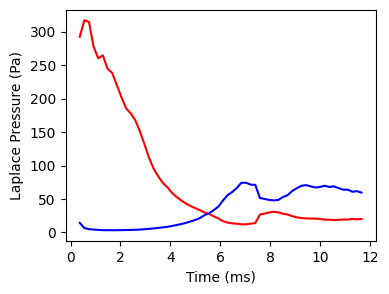

In [17]:
# Plot Laplace pressure over time
laplace_pressures_df = pd.DataFrame(laplace_pressures_with_time)
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(laplace_pressures_df['time_ms'], laplace_pressures_df['laplace_pressure_max'], label='Max Laplace Pressure', color='red')
ax.plot(laplace_pressures_df['time_ms'], laplace_pressures_df['laplace_pressure_min'], label='Min Laplace Pressure', color='blue')
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Laplace Pressure (Pa)")
print(f"Maximum Laplace Pressure: {laplace_pressures_df['laplace_pressure_max'].max()} Pa")
print(f"Minimum Laplace Pressure: {laplace_pressures_df['laplace_pressure_min'].min()} Pa")

In [18]:
hydrostatic_pressure = np.sqrt(2 * 9.81 * 3e-3)  # 3 mm depth
print(f"Hydrostatic Pressure at 3 mm depth: {hydrostatic_pressure} Pa")

Hydrostatic Pressure at 3 mm depth: 0.24261079942986874 Pa


In [19]:
def kappa(theta, a, b):
    num = (b**2 - a**2) * np.cos(theta)**2 + a**2
    den = (b**4 - a**4) * np.cos(2*theta) + a**4 + b**4
    return 2*np.sqrt(2) * a * b * (num / den)**1.5

In [20]:
# Get curvature at each point on an ellipse 
def get_curvature_at_each_point(x_data, y_data):
    # Calculate the first and second derivatives
    semimajor_axis = (x_data.max() - x_data.min()) / 2
    semiminor_axis = (y_data.max() - y_data.min()) / 2
    a = semimajor_axis
    b = semiminor_axis
    points_list = [(x, y) for x, y in zip(x_data, y_data)]
    curvature = []
    for i in range(len(points_list)):
        x, y = points_list[i]
        # Calculate the curvature using the formula
        theta = np.arctan2(y, x)
        curvature_value = kappa(theta, a, b)
        curvature.append(curvature_value)
    return np.array(curvature)

    

Maximum Laplace Pressure: 276.0087068945807 Pa at time 0.9248982611912689 ms
Minimum Laplace Pressure: 4.335460599334073 Pa at time 0.9248982611912689 ms


(-2.0, 2.0)

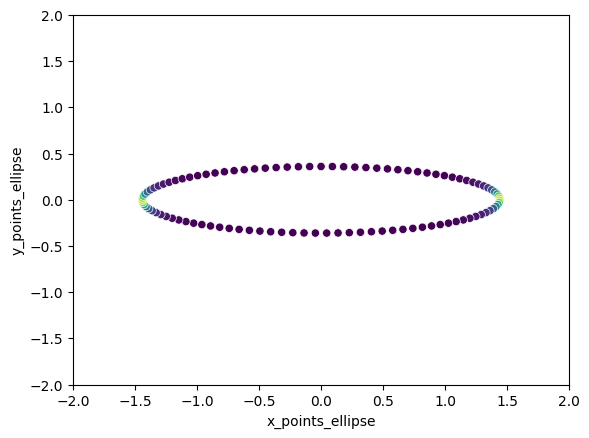

In [26]:
import warnings 
warnings.filterwarnings("ignore")
ellipse_points = all_times_df[all_times_df['time_ms'] == list(all_times_df['time_ms'].unique())[3]]
curvature = get_curvature_at_each_point(ellipse_points['x_points_ellipse']*1e-3, ellipse_points['y_points_ellipse']*1e-3)
ellipse_points['curvature'] = curvature
ellipse_points['laplace_pressure'] = ellipse_points['curvature'] * 0.025  # Assuming surface tension of 0.025 N/m
sns.scatterplot(x=ellipse_points['x_points_ellipse'], y=ellipse_points['y_points_ellipse'], hue=ellipse_points['laplace_pressure'], palette='viridis', hue_norm=plt.Normalize(vmin=10, vmax=300), legend=False)
print(f"Maximum Laplace Pressure: {ellipse_points['laplace_pressure'].max()} Pa at time {ellipse_points['time_ms'].values[0]} ms")  
print(f"Minimum Laplace Pressure: {ellipse_points['laplace_pressure'].min()} Pa at time {ellipse_points['time_ms'].values[0]} ms")
plt.xlim(-2, 2)
plt.ylim(-2, 2)